Practical: Hierarchical Clustering (Agglomerative) on Social Media User Data

1. Import Libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering


2. Create Dataset

In [14]:
# Social Media User data
data = {
    "User_ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Likes_per_Week": [5, 20, 30, 40, 60, 70, 80, 90, 100, 110],
    "Comments_per_Week": [2, 8, 12, 20, 30, 35, 40, 50, 55, 65]
}

df = pd.DataFrame(data)
df


,User_ID,Likes_per_Week,Comments_per_Week
0,1,5,2
1,2,20,8
2,3,30,12
3,4,40,20
4,5,60,30
5,6,70,35
6,7,80,40
7,8,90,50
8,9,100,55
9,10,110,65


3. Explore the Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   User_ID            10 non-null     int64
 1   Likes_per_Week     10 non-null     int64
 2   Comments_per_Week  10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes
None
        User_ID  Likes_per_Week  Comments_per_Week
count  10.00000       10.000000          10.000000
mean    5.50000       60.500000          31.700000
std     3.02765       35.625365          21.182015
min     1.00000        5.000000           2.000000
25%     3.25000       32.500000          14.000000
50%     5.50000       65.000000          32.500000
75%     7.75000       87.500000          47.500000
max    10.00000      110.000000          65.000000


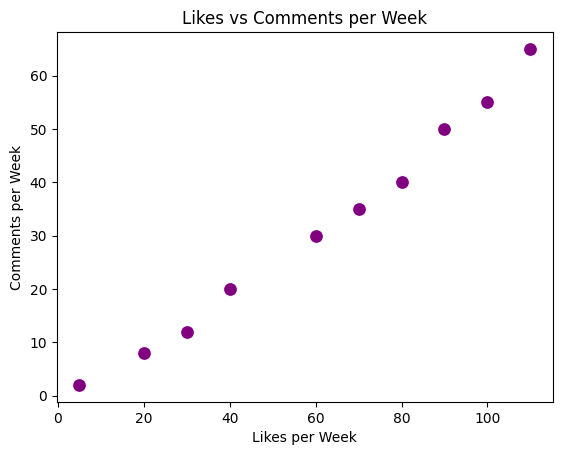

In [15]:
print(df.info())
print(df.describe())

sns.scatterplot(data=df, x="Likes_per_Week", y="Comments_per_Week", s=100, color="purple")
plt.title("Likes vs Comments per Week")
plt.xlabel("Likes per Week")
plt.ylabel("Comments per Week")
plt.show()


4. Standardize the Data

In [16]:
scaler = StandardScaler()
X = df[["Likes_per_Week", "Comments_per_Week"]]
X_scaled = scaler.fit_transform(X)


5. Plot Dendrogram

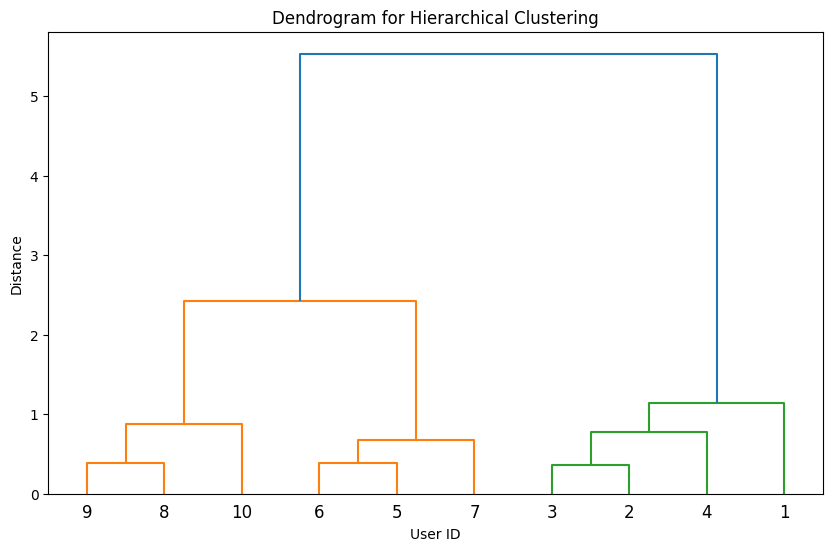

In [17]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(linked, labels=df["User_ID"].values, orientation="top", distance_sort="descending", show_leaf_counts=True)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("User ID")
plt.ylabel("Distance")
plt.show()


6. Apply Agglomerative Clustering

In [18]:
# From dendrogram, let's choose 2 clusters
cluster = AgglomerativeClustering(n_clusters=2, linkage="ward")
df["Cluster"] = cluster.fit_predict(X_scaled)


7. Visualize Clusters

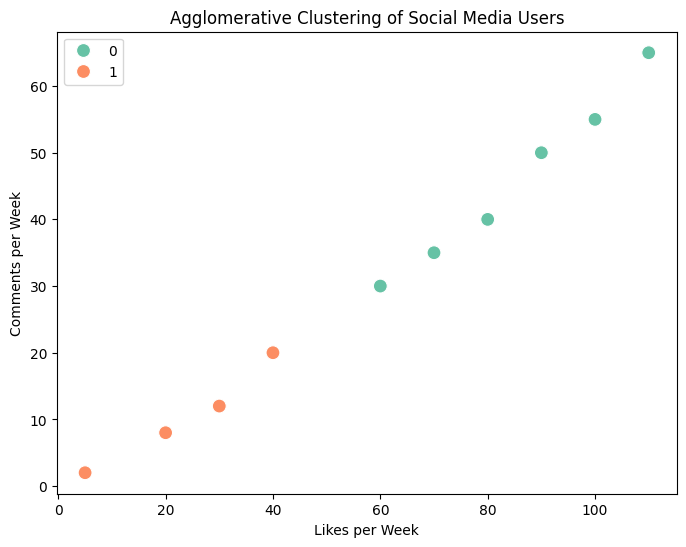

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Likes_per_Week", y="Comments_per_Week", hue="Cluster", palette="Set2", s=100)

plt.title("Agglomerative Clustering of Social Media Users")
plt.xlabel("Likes per Week")
plt.ylabel("Comments per Week")
plt.legend()
plt.show()


8. Output Clustered Data

In [20]:
print(df[["User_ID", "Likes_per_Week", "Comments_per_Week", "Cluster"]])


   User_ID  Likes_per_Week  Comments_per_Week  Cluster
0        1               5                  2        1
1        2              20                  8        1
2        3              30                 12        1
3        4              40                 20        1
4        5              60                 30        0
5        6              70                 35        0
6        7              80                 40        0
7        8              90                 50        0
8        9             100                 55        0
9       10             110                 65        0


Result Explanation:

The dendrogram helps visually choose the optimal number of clusters.

Agglomerative clustering grouped users based on their interaction patterns (likes and comments per week).

Scatter plot shows clusters in different colors.